In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 

In [3]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

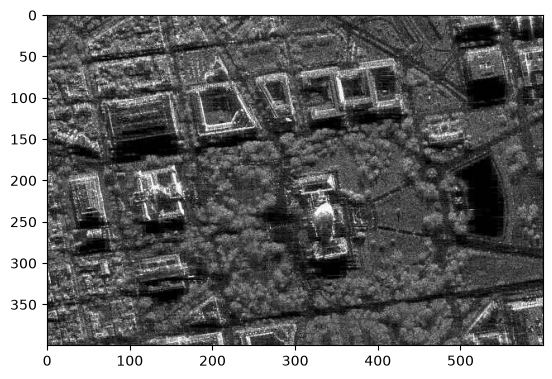

In [4]:
plt.imshow(image_gray, cmap='gray')

In [5]:
# 2. постройте гистограмму

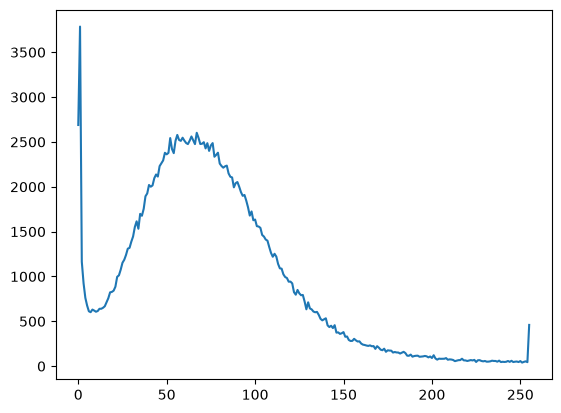

In [6]:
histSize = 256
histRange = (0, 256)

hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, False)
plt.plot(hist)
plt.show()

In [7]:
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

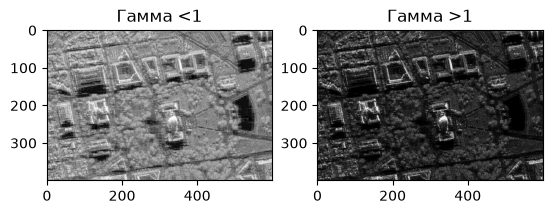

In [8]:
def gamma_correction(image, gamma):
    image_normalized = image / 255.0  #R_uncorrected/R_max
    R_corrected = np.power(image_normalized, gamma)
    return (R_corrected * 255).astype(np.uint8)

light_gray = gamma_correction(image_gray, 0.5)

dark_gray = gamma_correction(image_gray, 1.5)

plt.subplot(1, 2, 1)
plt.imshow(light_gray, cmap='gray')
plt.title("Гамма <1")

plt.subplot(1, 2, 2)
plt.imshow(dark_gray, cmap='gray')
plt.title("Гамма >1")

plt.show()

In [9]:
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

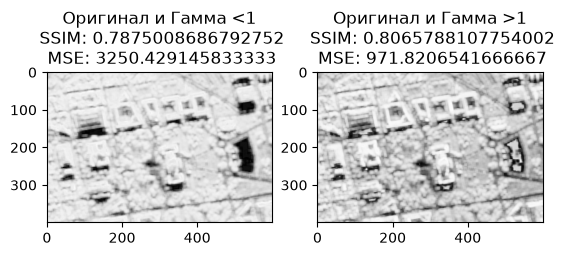

In [10]:
(ssim_light, diff_light) = structural_similarity(image_gray, light_gray, full=True)
diff_light = (diff_light * 255).astype("uint8")
plt.subplot(1, 2, 1)
plt.imshow(diff_light, cmap='gray')
mse_light = mean_squared_error(image_gray, light_gray)
plt.title(f"Оригинал и Гамма <1\n SSIM: {ssim_light}\n MSE: {mse_light}")

(ssim_dark, diff_dark) = structural_similarity(image_gray, dark_gray, full=True)
diff_dark = (diff_dark * 255).astype("uint8")
plt.subplot(1, 2, 2)
plt.imshow(diff_dark, cmap='gray')
mse_dark = mean_squared_error(image_gray, dark_gray)
plt.title(f"Оригинал и Гамма >1\n SSIM: {ssim_dark}\n MSE: {mse_dark}")

plt.show()

In [11]:
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

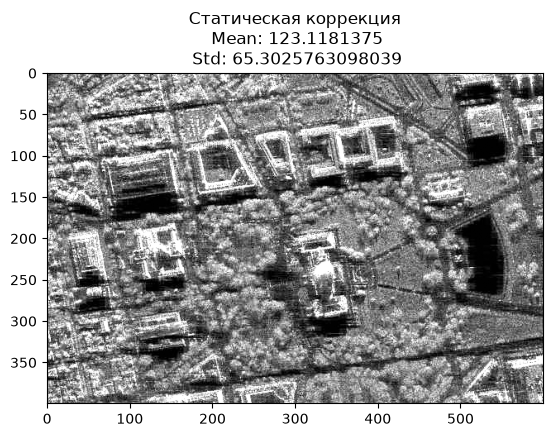

In [12]:
eq_gray = cv2.equalizeHist(image_gray)

#C_new = E_s + (C_t - E_t) * (D_s / D_t)
E_t = image_gray.mean()
D_t = image_gray.std()
E_s = eq_gray.mean()
D_s = eq_gray.std()
C_new = E_s + (image_gray.astype(np.float64) - E_t) * (D_s / D_t)
C_new = np.clip(C_new, 0, 255).astype(np.uint8)

plt.imshow(C_new, cmap='gray')
plt.title(f'Статическая коррекция\n Mean: {C_new.mean()}\n '
          f'Std: {C_new.std()}')

plt.show()

In [13]:
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

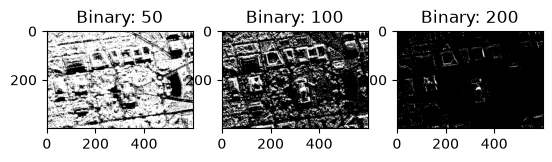

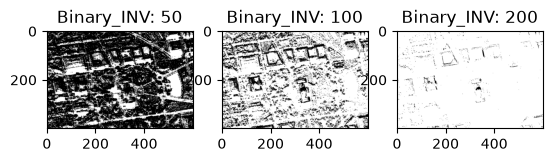

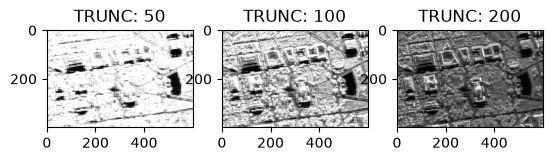

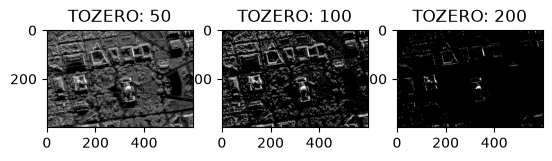

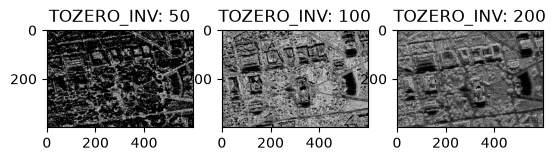

In [14]:
thresholds = [50, 100, 200]

for i, thresh_val in enumerate(thresholds):
    _, thresh_binary = cv2.threshold(image_gray, thresh_val, 255, cv2.THRESH_BINARY)
    plt.subplot(1, 3, i + 1)
    plt.imshow(thresh_binary, cmap='gray')
    plt.title(f'Binary: {thresh_val}')
plt.show()

for i, thresh_val in enumerate(thresholds):
    _, thresh_binary_inv = cv2.threshold(image_gray, thresh_val, 255, cv2.THRESH_BINARY_INV)
    plt.subplot(1, 3, i + 1)
    plt.imshow(thresh_binary_inv, cmap='gray')
    plt.title(f'Binary_INV: {thresh_val}')
plt.show()

for i, thresh_val in enumerate(thresholds):
    _, thresh_trunc = cv2.threshold(image_gray, thresh_val, 255, cv2.THRESH_TRUNC)
    plt.subplot(1, 3, i + 1)
    plt.imshow(thresh_trunc, cmap='gray')
    plt.title(f'TRUNC: {thresh_val}')
plt.show()

for i, thresh_val in enumerate(thresholds):
    _, thresh_tozero = cv2.threshold(image_gray, thresh_val, 255, cv2.THRESH_TOZERO)
    plt.subplot(1, 3, i + 1)
    plt.imshow(thresh_tozero, cmap='gray')
    plt.title(f'TOZERO: {thresh_val}')
plt.show()

for i, thresh_val in enumerate(thresholds):
    _, thresh_tozero_inv = cv2.threshold(image_gray, thresh_val, 255, cv2.THRESH_TOZERO_INV)
    plt.subplot(1, 3, i + 1)
    plt.imshow(thresh_tozero_inv, cmap='gray')
    plt.title(f'TOZERO_INV: {thresh_val}')
plt.show()
